# EDA de los datos finales de modelado

## Objetivo

Este notebook realiza un análisis exploratorio de los datos finales utilizados como punto de partida para los modelos predictivos de calidad del aire.

A diferencia del EDA inicial, realizado sobre los datos originales, este análisis se centra en el conjunto de datos resultante tras las etapas de preparación y transformación de los datos.

El objetivo principal es verificar que el dataset utilizado para modelado presenta una estructura y calidad adecuadas y establecer una base común para el desarrollo de los distintos modelos.

Se analizarán principalmente:

- estructura y cobertura temporal del dataset;
- número de estaciones y observaciones disponibles;
- presencia de valores ausentes;
- distribución de los contaminantes objetivo;
- presencia y comportamiento de valores extremos;
- evolución temporal de los contaminantes;
- posibles diferencias relevantes entre estaciones.

Los contaminantes considerados son:

- **NO₂**
- **O₃**
- **PM10**
- **PM2.5**

Los valores extremos identificados durante el análisis no serán eliminados automáticamente, ya que pueden corresponder a episodios reales de contaminación. Su naturaleza se estudiará antes de tomar cualquier decisión de preprocesamiento.

In [1]:
# ============================================================
# IMPORTS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# RUTA DEL PROYECTO
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "data").exists():
    ROOT = ROOT.parent

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: c:\Users\borja\Desktop\Master\TFM


In [3]:
# ============================================================
# ARCHIVOS DISPONIBLES
# ============================================================

for carpeta in ["processed", "enriched", "modeling"]:
    
    ruta = ROOT / "data" / carpeta
    
    if ruta.exists():
        print(f"\n--- {carpeta.upper()} ---")
        
        for archivo in ruta.iterdir():
            print(archivo.name)


--- PROCESSED ---

--- ENRICHED ---
dims
fact

--- MODELING ---
dataset_no2.parquet
mock.csv


In [4]:
# ============================================================
# ESTRUCTURA DE ENRICHED
# ============================================================

enriched_path = ROOT / "data" / "enriched"

for ruta in enriched_path.rglob("*"):
    if ruta.is_file():
        print(ruta.relative_to(ROOT))

data\enriched\dims\dim_estaciones_aire.parquet
data\enriched\dims\dim_estaciones_meteo.parquet
data\enriched\fact\calidad_aire_final.parquet
data\enriched\fact\meteo_final.parquet


## 1. Carga y estructura del dataset

Se utiliza como punto de partida la tabla final de calidad del aire generada durante el proceso de ingeniería de datos, antes de realizar las transformaciones específicas asociadas a cada modelo.

En primer lugar, se revisan su estructura, cobertura temporal, variables disponibles y número de observaciones.

In [5]:
# ============================================================
# CARGA DEL DATASET DE CALIDAD DEL AIRE
# ============================================================

path_aire = (
    ROOT
    / "data"
    / "enriched"
    / "fact"
    / "calidad_aire_final.parquet"
)

df_aire = pd.read_parquet(path_aire)

print("Shape:", df_aire.shape)
print("\nColumnas:")
print(df_aire.columns.tolist())

display(df_aire.head())

Shape: (102312, 11)

Columnas:
['provincia', 'municipio', 'estacion', 'magnitud', 'punto_muestreo', 'fecha', 'uom', 'uom_value', 'calidad', 'es_laborable_madrid_ciudad', 'extra']


,provincia,municipio,estacion,magnitud,punto_muestreo,fecha,uom,uom_value,calidad,es_laborable_madrid_ciudad,extra
0,28,79,40,8,28079040_8_8,2022-07-11,µg/m3,33.791667,0,True,"{""imputado"":false}"
1,28,79,40,8,28079040_8_8,2023-06-23,µg/m3,29.791667,0,True,"{""imputado"":false}"
2,28,79,40,8,28079040_8_8,2020-08-29,µg/m3,5.583333,0,False,"{""imputado"":false}"
3,28,79,40,8,28079040_8_8,2020-04-06,µg/m3,13.458333,0,True,"{""imputado"":false}"
4,28,79,40,8,28079040_8_8,2020-08-24,µg/m3,30.833333,0,True,"{""imputado"":false}"


In [6]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

df_aire.info()

<class 'pandas.DataFrame'>
RangeIndex: 102312 entries, 0 to 102311
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   provincia                   102312 non-null  int32  
 1   municipio                   102312 non-null  int32  
 2   estacion                    102312 non-null  int64  
 3   magnitud                    102312 non-null  int64  
 4   punto_muestreo              100934 non-null  str    
 5   fecha                       102312 non-null  object 
 6   uom                         100934 non-null  str    
 7   uom_value                   102312 non-null  float64
 8   calidad                     102312 non-null  int64  
 9   es_laborable_madrid_ciudad  102312 non-null  bool   
 10  extra                       102312 non-null  object 
dtypes: bool(1), float64(1), int32(2), int64(3), object(2), str(2)
memory usage: 9.0+ MB


In [7]:
# ============================================================
# COBERTURA TEMPORAL
# ============================================================

print("Fecha mínima:", df_aire["fecha"].min())
print("Fecha máxima:", df_aire["fecha"].max())

print(
    "Número de días:",
    df_aire["fecha"].nunique()
)

print(
    "Número de estaciones:",
    df_aire["estacion"].nunique()
)

print(
    "Número de contaminantes:",
    df_aire["magnitud"].nunique()
)

print(
    "\nMagnitudes disponibles:",
    sorted(df_aire["magnitud"].unique())
)

Fecha mínima: 2020-01-01
Fecha máxima: 2024-12-31
Número de días: 1827
Número de estaciones: 22
Número de contaminantes: 4

Magnitudes disponibles: [np.int64(8), np.int64(9), np.int64(10), np.int64(14)]


## 2. Completitud de los datos

Antes de analizar la distribución de los contaminantes, se comprueba la presencia de valores ausentes y el grado de completitud del conjunto de datos final.

También se analiza qué observaciones proceden de mediciones originales y cuáles han sido generadas mediante el procedimiento de imputación definido durante la ingeniería de datos.

Esta distinción resulta especialmente relevante para interpretar posteriormente la distribución y los valores extremos de cada contaminante.

In [8]:
# ============================================================
# VALORES AUSENTES
# ============================================================

nulos = pd.DataFrame({
    "n_nulos": df_aire.isna().sum(),
    "porcentaje": df_aire.isna().mean() * 100
})

display(
    nulos[nulos["n_nulos"] > 0]
    .sort_values("n_nulos", ascending=False)
    .round(2)
)

,n_nulos,porcentaje
punto_muestreo,1378,1.35
uom,1378,1.35


In [9]:
# ============================================================
# IDENTIFICACIÓN DE VALORES IMPUTADOS
# ============================================================

import json

def extraer_imputado(valor):
    if isinstance(valor, dict):
        return valor.get("imputado", False)
    
    if isinstance(valor, str):
        try:
            return json.loads(valor).get("imputado", False)
        except (json.JSONDecodeError, TypeError):
            return False
    
    return False


df_aire["imputado"] = (
    df_aire["extra"]
    .apply(extraer_imputado)
    .astype(bool)
)

print("Observaciones totales:", len(df_aire))
print("Observaciones reales:", (~df_aire["imputado"]).sum())
print("Observaciones imputadas:", df_aire["imputado"].sum())

print(
    "Porcentaje imputado:",
    f"{df_aire['imputado'].mean() * 100:.2f}%"
)

Observaciones totales: 102312
Observaciones reales: 100934
Observaciones imputadas: 1378
Porcentaje imputado: 1.35%


In [10]:
# ============================================================
# IMPUTACIÓN POR CONTAMINANTE
# ============================================================

nombres_contaminantes = {
    8: "NO2",
    9: "PM2.5",
    10: "PM10",
    14: "O3"
}

resumen_imputacion = (
    df_aire
    .groupby("magnitud")
    .agg(
        observaciones=("uom_value", "size"),
        imputadas=("imputado", "sum")
    )
    .reset_index()
)

resumen_imputacion["contaminante"] = (
    resumen_imputacion["magnitud"]
    .map(nombres_contaminantes)
)

resumen_imputacion["porcentaje_imputado"] = (
    resumen_imputacion["imputadas"]
    / resumen_imputacion["observaciones"]
    * 100
)

display(
    resumen_imputacion[
        [
            "contaminante",
            "observaciones",
            "imputadas",
            "porcentaje_imputado"
        ]
    ].round(2)
)

,contaminante,observaciones,imputadas,porcentaje_imputado
0,NO2,40194,245,0.61
1,PM2.5,14616,576,3.94
2,PM10,23751,330,1.39
3,O3,23751,227,0.96


In [11]:
# ============================================================
# RELACIÓN ENTRE IMPUTACIÓN Y NULOS DE METADATOS
# ============================================================

comprobacion = pd.crosstab(
    df_aire["imputado"],
    df_aire["uom"].isna(),
    rownames=["Imputado"],
    colnames=["uom es nulo"]
)

display(comprobacion)

print(
    "\nNulos en punto_muestreo:",
    df_aire["punto_muestreo"].isna().sum()
)

print(
    "Nulos en uom:",
    df_aire["uom"].isna().sum()
)

uom es nulo,False,True
Imputado,,
False,100934,0
True,0,1378



Nulos en punto_muestreo: 1378
Nulos en uom: 1378


### Interpretación de la completitud

El conjunto de datos final contiene 102.312 observaciones y no presenta valores ausentes en `uom_value`, variable que contiene las concentraciones utilizadas posteriormente para el modelado.

Se identifican 1.378 valores ausentes (1,35 %) en las variables `uom` y `punto_muestreo`. Estos registros coinciden exactamente con las observaciones generadas mediante el procedimiento de imputación. Por tanto, los valores ausentes corresponden únicamente a metadatos que no fueron reconstruidos al generar las observaciones imputadas y no afectan a las concentraciones utilizadas para modelado.

En total, el 1,35 % de las observaciones del conjunto de datos han sido imputadas. La proporción varía entre contaminantes: NO₂ presenta un 0,61 % de valores imputados, O₃ un 0,96 %, PM10 un 1,39 % y PM2.5 un 3,94 %.

Por tanto, no es necesario realizar ningún tratamiento adicional de valores ausentes sobre la variable objetivo antes del modelado.

In [12]:
# ============================================================
# PREPARACIÓN PARA EL ANÁLISIS
# ============================================================

df_aire["fecha"] = pd.to_datetime(df_aire["fecha"])

df_aire["contaminante"] = (
    df_aire["magnitud"]
    .map(nombres_contaminantes)
)

## 3. Distribución de los contaminantes objetivo

Se analiza la distribución de las concentraciones diarias de los cuatro contaminantes objetivo antes de su utilización en los modelos.

Además de las principales medidas descriptivas, se incluyen percentiles elevados para estudiar específicamente la cola superior de las distribuciones y detectar posibles concentraciones extremas.

Este análisis resulta especialmente relevante para PM10 y PM2.5, donde la inspección visual de las series temporales sugiere la presencia de algunos episodios con concentraciones considerablemente superiores a los valores habituales.

In [13]:
# ============================================================
# ESTADÍSTICOS DESCRIPTIVOS POR CONTAMINANTE
# ============================================================

resumen = (
    df_aire
    .groupby("contaminante")["uom_value"]
    .agg(
        n="count",
        media="mean",
        std="std",
        minimo="min",
        mediana="median",
        maximo="max"
    )
)

percentiles = (
    df_aire
    .groupby("contaminante")["uom_value"]
    .quantile([0.95, 0.99, 0.995, 0.999])
    .unstack()
)

percentiles.columns = [
    "P95",
    "P99",
    "P99.5",
    "P99.9"
]

resumen = resumen.join(percentiles)

display(
    resumen[
        [
            "n",
            "media",
            "std",
            "minimo",
            "mediana",
            "P95",
            "P99",
            "P99.5",
            "P99.9",
            "maximo"
        ]
    ].round(3)
)

,n,media,std,minimo,mediana,P95,P99,P99.5,P99.9,maximo
contaminante,,,,,,,,,,
NO2,40194,26.838,15.962,1.000,23.250,56.917,74.045,81.836,110.625,147.750
O3,23751,53.564,23.802,1.208,55.890,89.375,101.063,104.812,112.156,124.833
PM10,23751,18.917,15.042,1.000,15.708,41.583,68.479,81.958,121.750,467.500
PM2.5,14616,9.381,6.182,1.000,8.125,20.750,30.692,37.250,53.744,84.292


In [14]:
# ============================================================
# DETECCIÓN DE VALORES EXTREMOS MEDIANTE IQR
# ============================================================

resultados_iqr = []

for contaminante, grupo in df_aire.groupby("contaminante"):

    q1 = grupo["uom_value"].quantile(0.25)
    q3 = grupo["uom_value"].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = grupo[
        (grupo["uom_value"] < limite_inferior)
        | (grupo["uom_value"] > limite_superior)
    ]

    resultados_iqr.append({
        "contaminante": contaminante,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "n_outliers": len(outliers),
        "porcentaje_outliers": (
            len(outliers) / len(grupo) * 100
        )
    })

resultados_iqr = pd.DataFrame(resultados_iqr)

display(
    resultados_iqr.round(3)
)

,contaminante,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,porcentaje_outliers
0,NO2,14.792,35.875,21.083,-16.833,67.500,734,1.826
1,O3,35.625,71.833,36.208,-18.687,126.146,0,0.000
2,PM10,10.250,23.667,13.417,-9.875,43.792,991,4.172
3,PM2.5,5.167,11.838,6.671,-4.840,21.844,598,4.091


## 4. Análisis de valores extremos

El criterio IQR identifica una proporción relevante de observaciones extremas en PM10 (4,17 %) y PM2.5 (4,09 %), mientras que su incidencia es inferior en NO₂ (1,83 %) y nula en O₃.

La identificación estadística de una observación como outlier no implica necesariamente que se trate de un valor erróneo. En contaminantes atmosféricos pueden producirse episodios reales de concentraciones excepcionalmente elevadas.

Por este motivo, antes de aplicar cualquier tratamiento se estudian las observaciones situadas en la cola superior de las distribuciones, prestando especial atención a PM10 y PM2.5.

In [15]:
# ============================================================
# OBSERVACIONES MÁS EXTREMAS - PM10 Y PM2.5
# ============================================================

extremos_particulas = (
    df_aire[
        df_aire["contaminante"].isin(["PM10", "PM2.5"])
    ]
    .sort_values(
        ["contaminante", "uom_value"],
        ascending=[True, False]
    )
    .groupby("contaminante")
    .head(20)
)

display(
    extremos_particulas[
        [
            "contaminante",
            "fecha",
            "estacion",
            "uom_value",
            "imputado"
        ]
    ].sort_values(
        ["contaminante", "uom_value"],
        ascending=[True, False]
    )
)

,contaminante,fecha,estacion,uom_value,imputado
93276,PM10,2022-03-15,55,467.500000,False
101556,PM10,2022-03-15,40,448.166667,False
58378,PM10,2022-03-15,47,442.916667,False
101558,PM10,2022-03-15,36,433.833333,False
58375,PM10,2022-03-15,24,423.083333,False
93274,PM10,2022-03-15,50,412.208333,False
84036,PM10,2022-03-15,57,343.166667,False
58376,PM10,2022-03-15,60,282.500000,False
93273,PM10,2022-03-15,38,273.416667,False
93275,PM10,2022-03-15,48,251.125000,False


In [16]:
# ============================================================
# DÍAS CON MAYORES CONCENTRACIONES DE PARTÍCULAS
# ============================================================

resumen_diario_particulas = (
    df_aire[
        df_aire["contaminante"].isin(["PM10", "PM2.5"])
    ]
    .groupby(
        ["contaminante", "fecha"]
    )["uom_value"]
    .agg(
        media="mean",
        maximo="max",
        n_estaciones="count"
    )
    .reset_index()
)

for contaminante in ["PM10", "PM2.5"]:

    print(f"\n{contaminante} - días con mayor concentración media")

    display(
        resumen_diario_particulas[
            resumen_diario_particulas["contaminante"]
            == contaminante
        ]
        .nlargest(15, "media")
        .round(3)
    )


PM10 - días con mayor concentración media


C:\Users\borja\AppData\Local\Temp\ipykernel_1972\1112986842.py:30: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(3)


,contaminante,fecha,media,maximo,n_estaciones
804,PM10,2022-03-15,339.269,467.500,13
1765,PM10,2024-10-31,124.978,158.375,13
805,PM10,2022-03-16,99.484,129.222,13
896,PM10,2022-06-15,95.875,114.417,13
414,PM10,2021-02-18,87.288,120.167,13
415,PM10,2021-02-19,81.941,122.125,13
57,PM10,2020-02-27,79.770,102.583,13
427,PM10,2021-03-03,79.622,104.292,13
428,PM10,2021-03-04,79.293,100.917,13
557,PM10,2021-07-11,78.373,115.083,13



PM2.5 - días con mayor concentración media


C:\Users\borja\AppData\Local\Temp\ipykernel_1972\1112986842.py:30: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(3)


,contaminante,fecha,media,maximo,n_estaciones
2631,PM2.5,2022-03-15,63.224,84.292,8
2208,PM2.5,2021-01-16,56.370,66.125,8
2206,PM2.5,2021-01-14,43.545,48.667,8
2207,PM2.5,2021-01-15,42.070,46.750,8
2209,PM2.5,2021-01-17,40.144,45.500,8
2205,PM2.5,2021-01-13,38.088,43.417,8
1829,PM2.5,2020-01-03,37.529,45.667,8
2769,PM2.5,2022-07-31,37.196,69.773,8
2768,PM2.5,2022-07-30,36.727,69.909,8
2723,PM2.5,2022-06-15,32.995,41.625,8


### Interpretación de los valores extremos

El análisis mediante IQR identifica una proporción relevante de observaciones extremas en PM10 (4,17 %) y PM2.5 (4,09 %). Sin embargo, el análisis temporal y espacial muestra que los valores más elevados no corresponden generalmente a observaciones aisladas de una única estación.

El episodio más extremo se produce el 15 de marzo de 2022. En esta fecha, las 13 estaciones disponibles para PM10 registran una concentración media diaria de 339,27 µg/m³, alcanzándose un máximo de 467,50 µg/m³. Simultáneamente, las 8 estaciones de PM2.5 presentan una media de 63,22 µg/m³ y un máximo de 84,29 µg/m³.

Además, las concentraciones extremas observadas durante este episodio proceden mayoritariamente de mediciones originales y no del procedimiento de imputación. Se identifican también otros periodos en los que varias estaciones presentan concentraciones elevadas simultáneamente o durante varios días consecutivos.

Estos resultados indican que el criterio IQR está identificando principalmente episodios de contaminación excepcionalmente elevados respecto al comportamiento habitual de la serie, y no necesariamente errores de medición.

Por este motivo, se decide **mantener los valores extremos en el conjunto de datos utilizado para modelado**, evitando aplicar una eliminación automática de outliers. La capacidad de reproducir estos episodios constituye además una característica relevante a evaluar en los modelos predictivos.

## 5. Evolución temporal de los contaminantes

Finalmente, se representa la evolución temporal de las concentraciones medias diarias de cada contaminante.

Para facilitar la interpretación global y evitar que las diferencias entre estaciones dificulten la visualización, se calcula la concentración media diaria del conjunto de estaciones disponibles para cada contaminante.

Esta representación permite identificar la estacionalidad, los cambios de nivel y los principales episodios de concentraciones elevadas presentes durante el periodo analizado.

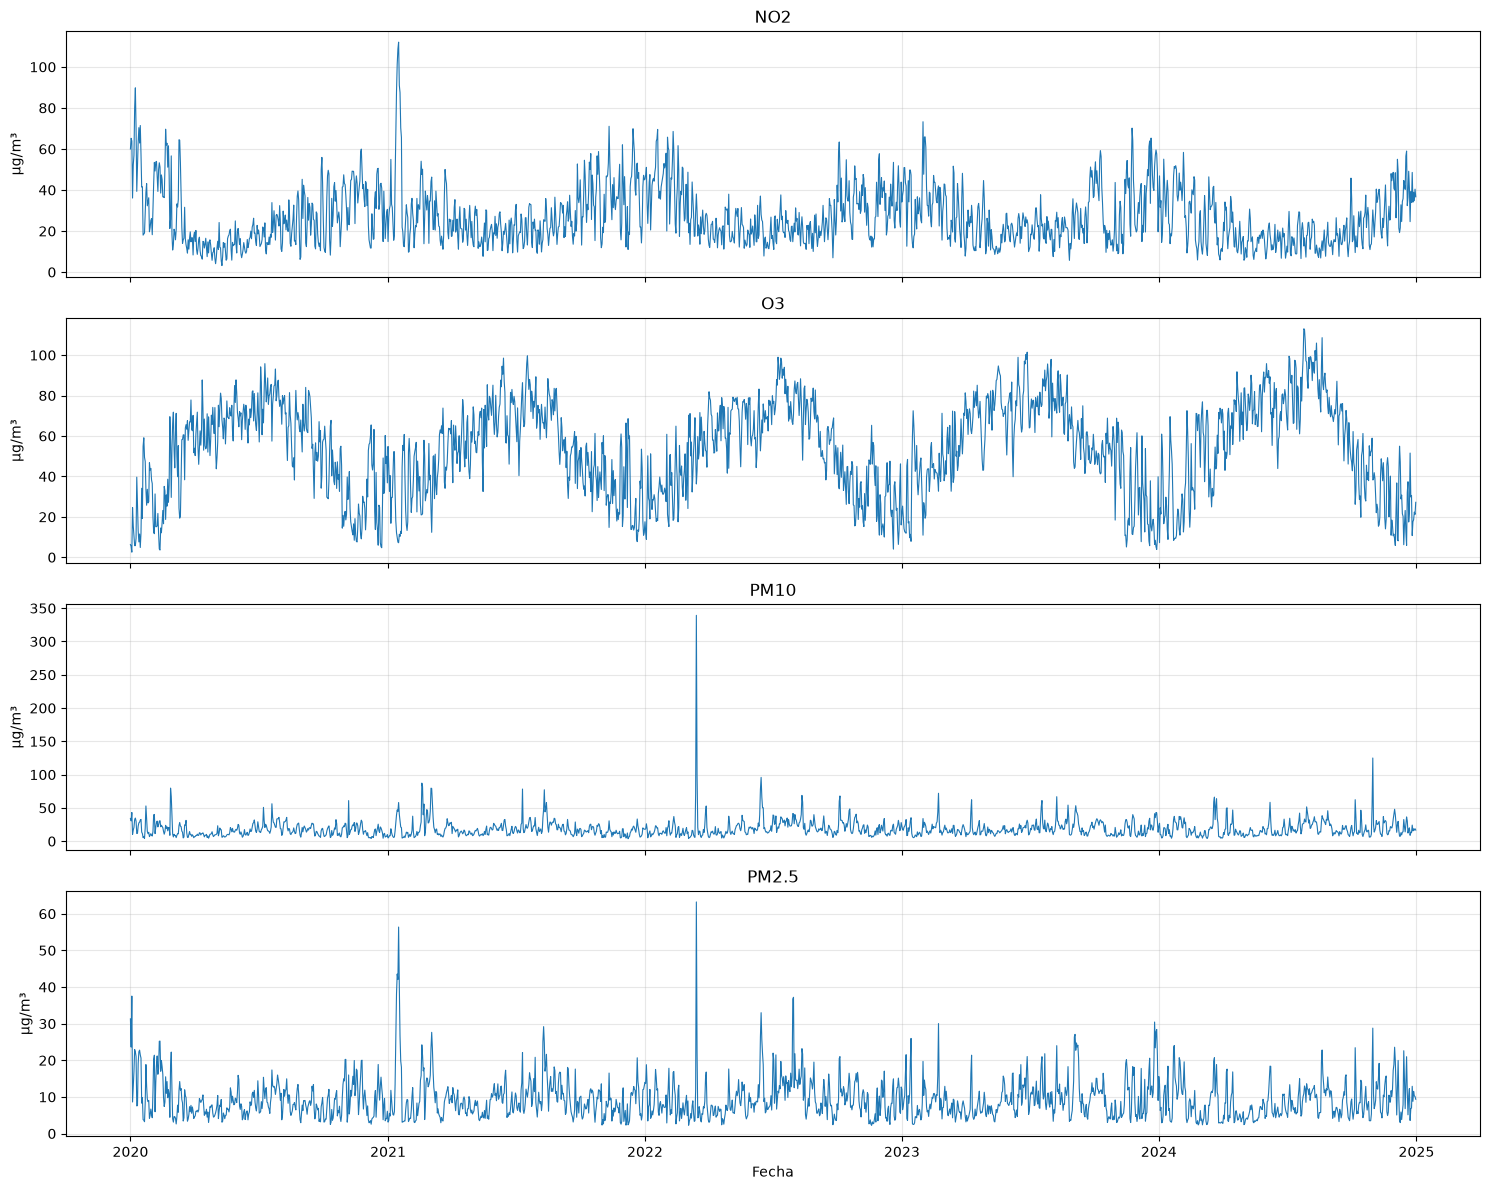

In [17]:
# ============================================================
# EVOLUCIÓN TEMPORAL MEDIA POR CONTAMINANTE
# ============================================================

serie_diaria = (
    df_aire
    .groupby(["fecha", "contaminante"])["uom_value"]
    .mean()
    .reset_index()
)

contaminantes = ["NO2", "O3", "PM10", "PM2.5"]

fig, axes = plt.subplots(
    len(contaminantes),
    1,
    figsize=(15, 12),
    sharex=True
)

for ax, contaminante in zip(axes, contaminantes):

    datos = serie_diaria[
        serie_diaria["contaminante"] == contaminante
    ]

    ax.plot(
        datos["fecha"],
        datos["uom_value"],
        linewidth=0.8
    )

    ax.set_title(contaminante)
    ax.set_ylabel("µg/m³")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

### Interpretación de la evolución temporal

Las series temporales muestran comportamientos diferenciados entre los cuatro contaminantes analizados.

El **NO₂** presenta variaciones estacionales, con concentraciones generalmente superiores durante los meses fríos y menores durante los meses cálidos. Aunque existen algunos episodios de concentraciones elevadas, estos son relativamente poco frecuentes.

El **O₃** muestra el patrón estacional más marcado, con máximos recurrentes durante los meses cálidos y mínimos durante los meses fríos. Este comportamiento regular es coherente con la ausencia de valores extremos detectados mediante el criterio IQR.

Las partículas **PM10 y PM2.5** presentan un comportamiento diferente, caracterizado por niveles habitualmente moderados y la aparición de episodios puntuales de concentraciones considerablemente elevadas. Destaca especialmente el episodio de marzo de 2022, visible simultáneamente en ambos contaminantes y en múltiples estaciones.

La coherencia temporal y espacial de estos episodios respalda la decisión de conservar los valores extremos en el conjunto de datos, al ser compatibles con episodios reales de elevada concentración y no con errores aislados de medición.

## 6. Cobertura de los contaminantes

La red de calidad del aire no mide necesariamente todos los contaminantes en todas las estaciones. Por este motivo, se analiza la cobertura disponible para cada contaminante antes de comenzar el modelado.

Se estudia el número de estaciones disponibles, el número de observaciones y la evolución anual de dicha cobertura, con el objetivo de comprobar que las series utilizadas presentan una disponibilidad suficientemente estable durante el periodo 2020-2024.

In [18]:
# ============================================================
# COBERTURA GENERAL POR CONTAMINANTE
# ============================================================

cobertura = (
    df_aire
    .groupby("contaminante")
    .agg(
        observaciones=("uom_value", "size"),
        estaciones=("estacion", "nunique"),
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max")
    )
    .reset_index()
)

display(cobertura)

,contaminante,observaciones,estaciones,fecha_inicio,fecha_fin
0,NO2,40194,22,2020-01-01,2024-12-31
1,O3,23751,13,2020-01-01,2024-12-31
2,PM10,23751,13,2020-01-01,2024-12-31
3,PM2.5,14616,8,2020-01-01,2024-12-31


In [19]:
# ============================================================
# COBERTURA ANUAL
# ============================================================

df_aire["anio"] = df_aire["fecha"].dt.year

cobertura_anual = (
    df_aire
    .groupby(["anio", "contaminante"])
    .agg(
        observaciones=("uom_value", "size"),
        estaciones=("estacion", "nunique")
    )
    .reset_index()
)

tabla_estaciones = (
    cobertura_anual
    .pivot(
        index="anio",
        columns="contaminante",
        values="estaciones"
    )
)

display(tabla_estaciones)

contaminante,NO2,O3,PM10,PM2.5
anio,,,,
2020,22,13,13,8
2021,22,13,13,8
2022,22,13,13,8
2023,22,13,13,8
2024,22,13,13,8


In [20]:
# ============================================================
# COMPLETITUD TEMPORAL POR ESTACIÓN Y CONTAMINANTE
# ============================================================

cobertura_estacion = (
    df_aire
    .groupby(["contaminante", "estacion"])
    .agg(
        observaciones=("fecha", "nunique"),
        fecha_inicio=("fecha", "min"),
        fecha_fin=("fecha", "max"),
        imputadas=("imputado", "sum")
    )
    .reset_index()
)

cobertura_estacion["cobertura_pct"] = (
    cobertura_estacion["observaciones"]
    / df_aire["fecha"].nunique()
    * 100
)

display(
    cobertura_estacion
    .sort_values(
        ["contaminante", "cobertura_pct"]
    )
    .round(2)
)

C:\Users\borja\AppData\Local\Temp\ipykernel_1972\3237997174.py:28: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,contaminante,estacion,observaciones,fecha_inicio,fecha_fin,imputadas,cobertura_pct
0,NO2,8,1827,2020-01-01,2024-12-31,3,100.0
1,NO2,16,1827,2020-01-01,2024-12-31,100,100.0
2,NO2,17,1827,2020-01-01,2024-12-31,1,100.0
3,NO2,18,1827,2020-01-01,2024-12-31,1,100.0
4,NO2,24,1827,2020-01-01,2024-12-31,27,100.0
5,NO2,27,1827,2020-01-01,2024-12-31,0,100.0
6,NO2,35,1827,2020-01-01,2024-12-31,73,100.0
7,NO2,36,1827,2020-01-01,2024-12-31,10,100.0
8,NO2,38,1827,2020-01-01,2024-12-31,0,100.0
9,NO2,39,1827,2020-01-01,2024-12-31,4,100.0


### Revisión de la cobertura y criterio de selección de estaciones

El análisis de la imputación permitió detectar diferencias en la disponibilidad histórica de determinadas combinaciones estación-contaminante.

En general, la proporción de valores imputados es reducida y corresponde principalmente a ausencias puntuales dentro de series con cobertura suficiente. Estas observaciones se mantienen, ya que permiten conservar la continuidad temporal de las series.

Sin embargo, se detectó un caso particular en **PM2.5 para la estación 57**. Durante el año 2020 no existe ninguna observación original para esta combinación, por lo que las 366 observaciones correspondientes a dicho año habían sido reconstruidas mediante imputación. En total, esta estación presenta 368 valores imputados durante el periodo analizado.

La reconstrucción de un año completo se considera diferente de la imputación de ausencias puntuales, ya que el modelo estaría utilizando durante un periodo prolongado concentraciones estimadas en lugar de observaciones reales.

Por este motivo, se establece como criterio que **no se utilizará la estación 57 para el modelado de PM2.5**. Se prioriza así trabajar únicamente con estaciones que dispongan de una cobertura histórica real suficiente para el contaminante objetivo.

Las imputaciones puntuales presentes en el resto de estaciones se mantienen, dado que representan una proporción reducida de las observaciones y permiten preservar la continuidad de las series temporales.

### Interpretación de la cobertura

Ahora el conjunto de datos presenta una cobertura temporal completa durante el periodo 2020-2024 para todas las combinaciones válidas de estación y contaminante.

El número de estaciones disponibles permanece constante durante los cinco años analizados: 22 estaciones para NO₂, 13 para O₃, 13 para PM10 y 8 para PM2.5. Cada estación dispone de 1.827 observaciones diarias, correspondientes a la totalidad de los días comprendidos entre el 1 de enero de 2020 y el 31 de diciembre de 2024.

Las diferencias en el número total de observaciones entre contaminantes se deben, por tanto, al diferente número de estaciones que monitorizan cada uno de ellos y no a diferencias en su cobertura temporal.

La cobertura completa se consigue tras el procedimiento de imputación aplicado durante la preparación de los datos. En general, el número de observaciones imputadas por estación es reducido.

En conjunto, los datos presentan una estructura temporal regular y adecuada para su utilización posterior en modelos predictivos.

# 7. Conclusiones del análisis exploratorio

El análisis realizado permite validar la estructura y calidad del conjunto de datos de contaminación atmosférica que se utilizará como base para el posterior modelado predictivo.

## Estructura del conjunto de datos

El periodo analizado comprende desde el **1 de enero de 2020 hasta el 31 de diciembre de 2024**, con un total de **1.827 días**.

Se consideran cuatro contaminantes:

- **NO₂:** 22 estaciones y 40.194 observaciones.
- **O₃:** 13 estaciones y 23.751 observaciones.
- **PM10:** 13 estaciones y 23.751 observaciones.
- **PM2.5:** 8 estaciones y 14.616 observaciones.

Las diferencias en el número de observaciones se deben a que no todas las estaciones monitorizan todos los contaminantes.

## Cobertura e imputación

Tras el proceso de preparación de los datos, cada combinación válida de estación y contaminante dispone de una observación para cada uno de los 1.827 días del periodo analizado.

De las **102.312 observaciones totales**, 100.934 corresponden a mediciones originales y 1.378 a valores imputados, lo que supone únicamente un **1,35 % de imputación global**.

Es importante distinguir entre dos situaciones:

1. **Ausencias estructurales:** una estación no monitoriza un determinado contaminante. Estas ausencias pueden aparecer como valores nulos al transformar los datos a formato ancho y no deben considerarse datos perdidos ni ser imputadas.

2. **Ausencias en series monitorizadas:** una estación sí monitoriza habitualmente el contaminante, pero existen días sin observaciones. Estas ausencias han sido tratadas mediante el procedimiento de imputación definido durante la preparación de los datos.

Aunque la imputación global es reducida, su distribución temporal no es completamente homogénea. Se identifican algunos periodos estación-contaminante con porcentajes elevados de imputación.

## Valores extremos

La aplicación del criterio IQR identifica valores extremos principalmente en:

- **NO₂:** 1,83 %.
- **PM10:** 4,17 %.
- **PM2.5:** 4,09 %.
- **O₃:** 0 %.

Sin embargo, el análisis temporal y espacial muestra que una parte importante de estos valores no corresponde a observaciones aisladas.

Destaca especialmente el episodio del **15 de marzo de 2022**, cuando las concentraciones de PM10 aumentan simultáneamente en múltiples estaciones, alcanzando una concentración media de **339,27 µg/m³** y un máximo de **467,50 µg/m³**. El mismo día se observa también un incremento generalizado de PM2.5.

La presencia simultánea de concentraciones elevadas en múltiples estaciones indica que el criterio estadístico IQR está identificando episodios excepcionalmente elevados respecto a la distribución habitual, pero no necesariamente errores de medición.

Por este motivo, **no se realiza una eliminación automática de outliers**. Estos episodios se conservan en el conjunto de datos, ya que forman parte del comportamiento que los modelos predictivos deberían ser capaces de representar.

## Comportamiento temporal

Las series muestran comportamientos diferenciados según el contaminante.

El **NO₂** presenta una componente estacional apreciable, con concentraciones generalmente superiores durante los meses fríos y menores durante los meses cálidos.

El **O₃** presenta una estacionalidad anual especialmente marcada, con máximos recurrentes durante los meses cálidos y mínimos durante los meses fríos.

Las partículas **PM10 y PM2.5** presentan niveles habitualmente moderados combinados con episodios puntuales de concentraciones considerablemente elevadas.

Estos patrones confirman la relevancia de incorporar adecuadamente la **componente temporal** durante el posterior proceso de modelado.

## Decisiones para el modelado

A partir de este análisis se establecen las siguientes decisiones como base de partida:

- Mantener las observaciones extremas, evitando una eliminación automática basada únicamente en criterios estadísticos como el IQR.
- Utilizar únicamente las combinaciones estación-contaminante realmente monitorizadas.
- No interpretar como valores perdidos las ausencias estructurales generadas al pivotar contaminantes que no son medidos por determinadas estaciones.
- Para el modelado de PM2.5 se excluirá específicamente la estación 57, debido a que la totalidad de sus observaciones correspondientes a 2020 (366 días) fueron generadas mediante imputación. De este modo, el modelo de PM2.5 utilizará 7 de las 8 estaciones presentes originalmente en el dataset final de calidad del aire.
- Mantener identificadas las observaciones procedentes de imputación para poder evaluar su posible impacto.
- Revisar específicamente los periodos prolongados con elevada imputación antes de establecer el dataset definitivo común.
- Mantener la estructura temporal de los datos y evitar procedimientos de partición aleatoria que puedan introducir fuga de información entre periodos.

En conjunto, el dataset presenta una **cobertura temporal elevada, una proporción global reducida de imputación y patrones temporales coherentes**, por lo que constituye una base adecuada para el desarrollo de los modelos predictivos, teniendo en cuenta las consideraciones anteriores.